In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import pairwise_distances
from datetime import datetime
from concurrent.futures import ThreadPoolExecutor, as_completed
import copy
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import pickle
import sys

# Load

In [ ]:
path = "D:\\Research"

In [10]:
artnet_2024 = pd.read_excel(f"{path}\\Creativity_Artnet\\Datasets\\ArtNet\\Artnet_Europe_2024_merged.xlsx")

In [11]:
artnet_2024_embed = np.load(f"{path}\\Creativity_Artnet\\Datasets\\clip_embedding_2024.npy",allow_pickle=True)

In [35]:
year_to_prior = {}
current_prior = set()
print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}: Start Building Prior Knowledge")
for year in sorted(artnet_2024["workyear from"].unique()):
    year_rows_index = artnet_2024[artnet_2024["workyear from"] == year].index
    year_to_prior[year] = copy.deepcopy(current_prior)  # store snapshot before update
    current_prior |= set(year_rows_index)
print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}: Finish Building Prior Knowledge")

2025-12-09 04:43:08: Start Building Prior Knowledge
2025-12-09 04:43:19: Finish Building Prior Knowledge


In [37]:
BASELINE_YEAR=1600

In [38]:
print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}: Start Building Prior Model")
gmms=[]
for year in sorted(artnet_2024["workyear from"].unique()):
    if year < BASELINE_YEAR:
        continue
    prior_knowledge = artnet_2024_embed_reduced[list(year_to_prior.get(year, set()))]
    gmm = GaussianMixture(n_components=20, covariance_type='diag',reg_covar=1e-3) # 20 is a good amount of components
    gmm.fit(prior_knowledge)
    gmms.append(gmm)
    with open(f"ViT_gmm_{year}.pkl", "wb") as f:
        pickle.dump(gmm, f)
    if year%25 ==0:
        print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}: Currently at year {year}")
        
print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}: Finish Building Prior Model")

2025-12-09 04:44:54: Start Building Prior Model
2025-12-09 04:44:54: Currently at year 1600
2025-12-09 04:45:02: Currently at year 1625
2025-12-09 04:45:11: Currently at year 1650
2025-12-09 04:45:21: Currently at year 1675
2025-12-09 04:45:28: Currently at year 1700
2025-12-09 04:45:36: Currently at year 1725
2025-12-09 04:45:48: Currently at year 1750
2025-12-09 04:45:58: Currently at year 1775
2025-12-09 04:46:08: Currently at year 1800
2025-12-09 04:46:18: Currently at year 1825
2025-12-09 04:46:31: Currently at year 1850
2025-12-09 04:46:44: Currently at year 1875
2025-12-09 04:46:57: Currently at year 1900
2025-12-09 04:47:38: Currently at year 1925
2025-12-09 04:48:57: Currently at year 1950
2025-12-09 04:50:40: Currently at year 1975
2025-12-09 04:52:38: Currently at year 2000
2025-12-09 04:53:37: Finish Building Prior Model


In [41]:
gmms_by_year={}
count=0
for year in sorted(artnet_2024["workyear from"].unique()):
    if year < BASELINE_YEAR:
        continue
    prior_knowledge = artnet_2024_embed_reduced[list(year_to_prior.get(year, set()))]
    gmm = gmms[count]
    count+=1
    gmms_by_year[year] = gmm
    if year%25 ==0:
        print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}: Currently at year {year}")

2025-12-09 05:00:07: Currently at year 1600
2025-12-09 05:00:07: Currently at year 1625
2025-12-09 05:00:07: Currently at year 1650
2025-12-09 05:00:07: Currently at year 1675
2025-12-09 05:00:07: Currently at year 1700
2025-12-09 05:00:07: Currently at year 1725
2025-12-09 05:00:07: Currently at year 1750
2025-12-09 05:00:08: Currently at year 1775
2025-12-09 05:00:08: Currently at year 1800
2025-12-09 05:00:08: Currently at year 1825
2025-12-09 05:00:08: Currently at year 1850
2025-12-09 05:00:08: Currently at year 1875
2025-12-09 05:00:08: Currently at year 1900
2025-12-09 05:00:08: Currently at year 1925
2025-12-09 05:00:08: Currently at year 1950
2025-12-09 05:00:09: Currently at year 1975
2025-12-09 05:00:10: Currently at year 2000


In [42]:
with open(f"gmm_dict.pkl", "wb") as f:
    pickle.dump(gmms_by_year, f)

In [47]:
sys.getsizeof(gmms_by_year)

18512

In [88]:
def pointwise_surprise(x, gmm_P):
    x = x.reshape(1, -1) 
    log_prob = gmm_P.score(x)
    return -log_prob  # higher means more surprising

In [89]:
def compute_surprise(i,year, gmms_by_year,embedding,BASELINE_YEAR):
    if year <= BASELINE_YEAR:  # pre-year baseline
        return i, 0
    # print(f"The total steps are: {playcount}")
    # mark new pairs not in prior knowledge
    gmm = gmms_by_year[year]
    surprise = pointwise_surprise(embedding,gmm)
    return i, surprise

In [90]:
number_size = 100000
range_start = 0
range_end = min(range_start+number_size,artnet_2024.shape[0])
N = min(number_size, artnet_2024.shape[0]-range_start)
max_workers = 20
BASELINE_YEAR=1600
print(f"{datetime.now():%Y-%m-%d %H:%M:%S}: Start")
while range_start < artnet_2024.shape[0]:
    print(f"{datetime.now():%Y-%m-%d %H:%M:%S}: Now at {range_start}")
    surprise = np.zeros(N)
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {
            ex.submit(compute_surprise, i, 
                    artnet_2024.iloc[i]["workyear from"],
                    gmms_by_year,
                    artnet_2024_embed_reduced[i],
                    BASELINE_YEAR): i
            for i in range(range_start,range_end)
        }
        completed = 0
        for fut in as_completed(futures):
            i,row_surprise = fut.result()
            surprise[i-range_start]  = row_surprise
            completed += 1
            if completed % 10000 == 0:
                print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}: Completed {completed}/{artnet_2024.shape[0]}")
    print(f"{datetime.now():%Y-%m-%d %H:%M:%S}: Saving embeddings")
    np.save(f"{path}\\Creativity_Artnet\\Datasets\\Surprise_2024\\surprise_{range_start}.npy", surprise)
    print(f"{datetime.now():%Y-%m-%d %H:%M:%S}: Embedding Saved")
    range_start = range_start + N
    range_end = min(range_start+number_size,artnet_2024.shape[0])
    N = min(number_size, artnet_2024.shape[0]-range_start)
print(f"{datetime.now():%Y-%m-%d %H:%M:%S}: Ends")

2025-12-09 06:10:46: Start
2025-12-09 06:10:46: Now at 0
2025-12-09 06:11:30: Completed 10000/355551
2025-12-09 06:11:30: Completed 20000/355551
2025-12-09 06:11:30: Completed 30000/355551
2025-12-09 06:11:30: Completed 40000/355551
2025-12-09 06:11:30: Completed 50000/355551
2025-12-09 06:11:30: Completed 60000/355551
2025-12-09 06:11:30: Completed 70000/355551
2025-12-09 06:11:31: Completed 80000/355551
2025-12-09 06:11:31: Completed 90000/355551
2025-12-09 06:11:31: Completed 100000/355551
2025-12-09 06:11:31: Saving embeddings
2025-12-09 06:11:31: Embedding Saved
2025-12-09 06:11:31: Now at 100000
2025-12-09 06:12:12: Completed 10000/355551
2025-12-09 06:12:12: Completed 20000/355551
2025-12-09 06:12:12: Completed 30000/355551
2025-12-09 06:12:13: Completed 40000/355551
2025-12-09 06:12:13: Completed 50000/355551
2025-12-09 06:12:13: Completed 60000/355551
2025-12-09 06:12:13: Completed 70000/355551
2025-12-09 06:12:13: Completed 80000/355551
2025-12-09 06:12:13: Completed 90000/35

# Merge

In [91]:
import pickle
import glob

In [92]:
folder_path = "D:\\MissTiny\\GitHub\\Creativity_Artnet\\Datasets\\Surprise_2024"
npy_files = glob.glob(f"{folder_path}/*.npy")

In [93]:
arrays = [np.load(f, allow_pickle=True) for f in npy_files]
big_array = np.concatenate(arrays, axis=0)
np.save("D:\\MissTiny\\GitHub\\Creativity_Artnet\\Datasets\\surprise_2024.npy", big_array)

In [94]:
big_array.shape

(355551,)

In [95]:
surprise_array = np.vstack(big_array)

In [96]:
np.save("D:\\MissTiny\\GitHub\\Creativity_Artnet\\Datasets\\surprise_2024.npy", surprise_array)

In [97]:
surprise_array.shape

(355551, 1)

# Test

In [17]:
print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}: PCA Start")
pca = PCA(n_components=16)  # or 5, based on explained variance
artnet_2024_embed_reduced = pca.fit_transform(artnet_2024_embed)
print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}: PCA End")

2025-12-09 04:00:31: Start Building Prior Knowledge
2025-12-09 04:00:31: Finish Building Prior Knowledge


In [21]:
ks = range(1, 21)
bics = []
print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}: Start")
for k in ks:
    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=0)
    gmm.fit(artnet_2024_embed_reduced)
    bics.append(gmm.bic(artnet_2024_embed_reduced))
    print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}: Currently at {k}")
best_k = ks[np.argmin(bics)]
print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}: End")

2025-12-09 04:01:52: Start
2025-12-09 04:01:53: Currently at 1
2025-12-09 04:01:57: Currently at 2
2025-12-09 04:02:04: Currently at 3
2025-12-09 04:02:11: Currently at 4
2025-12-09 04:02:28: Currently at 5
2025-12-09 04:02:44: Currently at 6
2025-12-09 04:03:07: Currently at 7
2025-12-09 04:03:40: Currently at 8
2025-12-09 04:04:22: Currently at 9
2025-12-09 04:04:48: Currently at 10
2025-12-09 04:05:18: Currently at 11
2025-12-09 04:05:50: Currently at 12
2025-12-09 04:06:56: Currently at 13
2025-12-09 04:07:33: Currently at 14
2025-12-09 04:08:34: Currently at 15
2025-12-09 04:09:40: Currently at 16
2025-12-09 04:10:59: Currently at 17
2025-12-09 04:12:04: Currently at 18
2025-12-09 04:13:08: Currently at 19
2025-12-09 04:14:22: Currently at 20
2025-12-09 04:14:22: End


In [27]:
ks = range(21, 30)
print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}: Start")
for k in ks:
    gmm = GaussianMixture(n_components=k, covariance_type="full", random_state=0)
    gmm.fit(artnet_2024_embed_reduced)
    bics.append(gmm.bic(artnet_2024_embed_reduced))
    print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}: Currently at {k}")

print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}: End")

2025-12-09 04:16:46: Start
2025-12-09 04:18:26: Currently at 21
2025-12-09 04:19:33: Currently at 22
2025-12-09 04:20:42: Currently at 23
2025-12-09 04:22:05: Currently at 24
2025-12-09 04:23:34: Currently at 25
2025-12-09 04:25:02: Currently at 26
2025-12-09 04:26:52: Currently at 27
2025-12-09 04:28:25: Currently at 28
2025-12-09 04:30:11: Currently at 29


IndexError: range object index out of range

In [28]:
np.save("gmm_component.npy", bics)

In [32]:
ks = range(1, 30)
best_k = ks[np.argmin(bics)]
print(f"Best k is {best_k}")

Best k is 29


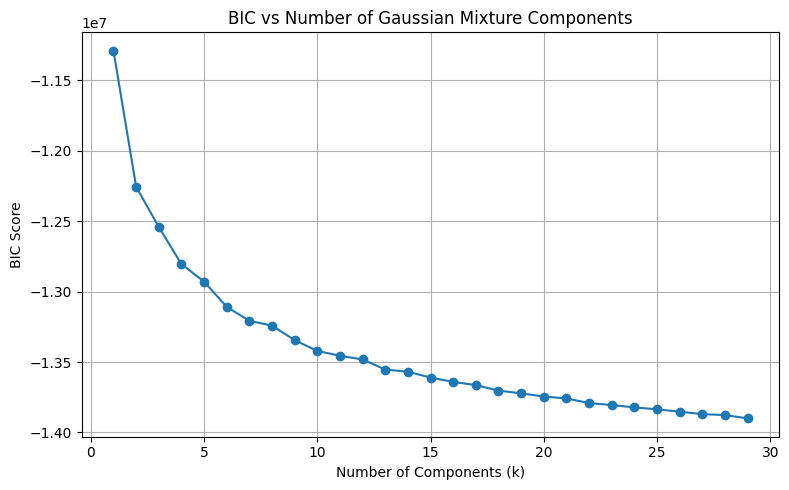

In [30]:
plt.figure(figsize=(8, 5))
plt.plot(list(ks), bics, marker='o')
plt.xlabel("Number of Components (k)")
plt.ylabel("BIC Score")
plt.title("BIC vs Number of Gaussian Mixture Components")
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
plt.savefig("bic_vs_k.jpg", dpi=300)

<Figure size 640x480 with 0 Axes>

In [26]:
best_k

20

In [ ]:
for i in range(artnet_2024_embed_reduced.shape[0]):
    row_dict = artnet_2024.iloc[i]
    year = row_dict["workyear from"]
    if year <= BASELINE_YEAR:  # pre-year baseline
        break
        return i, 0
    prior_knowledge = artnet_2024_embed_reduced[list(year_to_prior.get(year, set()))]
    A = embeddings[i]
    gmm = GaussianMixture(n_components=20, covariance_type='diag',reg_covar=1e-3)
    gmm.fit(prior_knowledge)
    print()

In [ ]:
def pointwise_surprise(x, gmm_P):
    x = x.reshape(1, -1) 
    log_prob = gmm_P.score(x)
    return -log_prob  # higher means more surprising

In [ ]:
surprise_raw1 = np.zeros(artnet_2024_embed_reduced.shape[0])
gmms1=[]
for i in range(len(date_list)-2):
    baseline_date=date_list[i+1]
    baseline_indx = np.where(temp_rank['date']<=baseline_date)
    #print(baseline_indx)
    baseline_group = clip_embedding_wikiart_reduced[baseline_indx]
    evaluate_date = date_list[i+2]
    evaluate_indx=np.where(temp_rank['date']==evaluate_date)
    evaluate_group = clip_embedding_wikiart_reduced[evaluate_indx]
    gmm1 = GaussianMixture(n_components=2, covariance_type='diag',reg_covar=1e-3)
    gmm1.fit(baseline_group)
    gmms1.append(gmm1)
    for i in range(len(evaluate_indx[0])):
        surprise_raw1[evaluate_indx[0][i]] = pointwise_surprise(clip_embedding_wikiart_reduced[evaluate_indx[0][i]],gmm1)

In [79]:
i=0
row = artnet_2024.iloc[i]
year = artnet_2024.iloc[i]["workyear from"]

In [58]:

idx, surprise1 = compute_surprise(i, year, gmms_by_year, artnet_2024_embed_reduced[i], BASELINE_YEAR)

In [59]:
surprise

np.float64(-18.749726886993752)

In [60]:
pointwise_surprise(artnet_2024_embed_reduced[i], gmms_by_year[year])

np.float64(-18.749726886993752)

In [85]:
artnet_2024_embed_reduced[i].reshape(1, -1).shape

(1, 16)

In [65]:
gmm = gmms_by_year[year]

In [86]:
log_prob = gmm.predict(artnet_2024_embed_reduced[i].reshape(1, -1))

In [87]:
log_prob

array([17])